# 08 · Predictive EDA — where the model is right, wrong, and useful
### The Outliers · Mumbai Rent Radar

A fair-rent model is only useful if we know *where to trust it*. Here we turn predictions
back on the city: which zones and price bands it nails, where it struggles, and — the actual
product — **which live listings look mispriced** against the model's fair estimate.

**Input:** `final_model.joblib`, `test_scored.csv` + locality coordinates

In [2]:
import sys, warnings
sys.path.append("../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import style
warnings.filterwarnings("ignore")
style.setup()

s = pd.read_csv("../data/processed/test_scored.csv")
att = pd.read_csv("../data/processed/locality_attributes.csv")
s = s.merge(att[["locality_name", "latitude", "longitude", "zone"]].rename(columns={"zone": "zone_a"}),
            on="locality_name", how="left")
s["resid"] = s["rent"] - s["pred_rent"]                 # +ve = costs more than fair
s["ape"] = np.abs(s["resid"]) / s["rent"] * 100
s["pct_off"] = s["resid"] / s["pred_rent"] * 100
print("Scored test listings:", len(s), "| median error {:.1f}%".format(s["ape"].median()))

Scored test listings: 1000 | median error 26.7%


## 1 · The error grows with price (and that's expected)
Residuals vs predicted rent: a funnel. Cheap flats are pinned down tightly; luxury flats
scatter, because a handful of features can't capture what makes a ₹3L flat special.

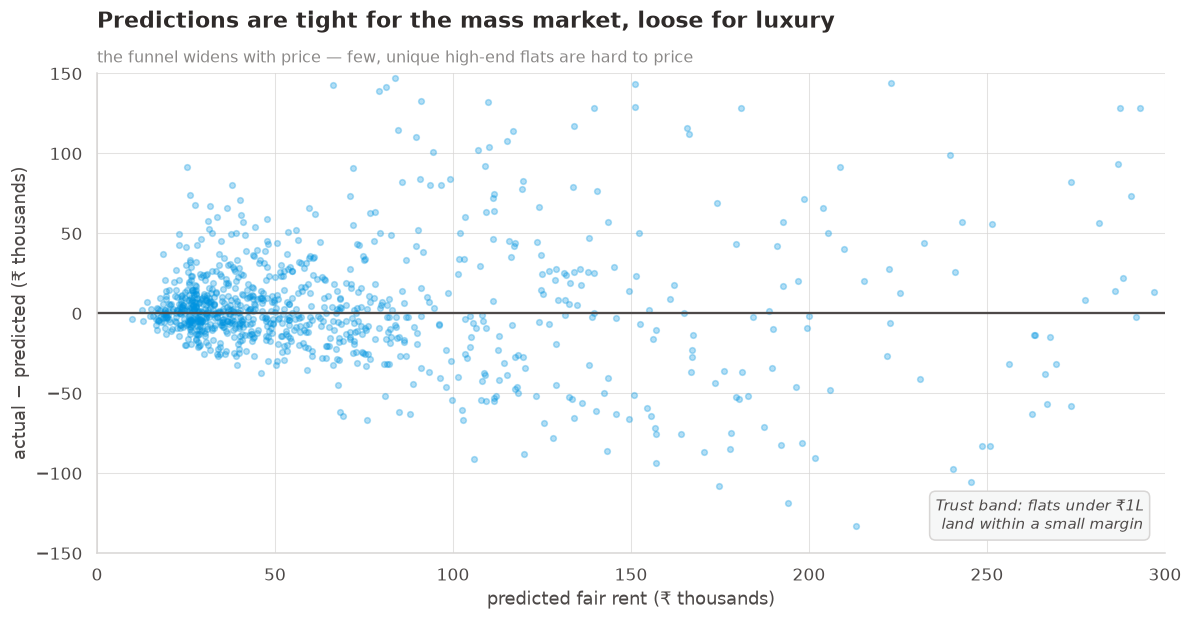

In [3]:
fig, ax = plt.subplots(figsize=(11, 5.8))
ax.scatter(s["pred_rent"] / 1000, s["resid"] / 1000, s=14, alpha=0.3, color=style.BLUE)
ax.axhline(0, color=style.CHARCOAL, lw=1.5)
ax.set_xlim(0, 300); ax.set_ylim(-150, 150)
ax.set_xlabel("predicted fair rent (₹ thousands)"); ax.set_ylabel("actual − predicted (₹ thousands)")
style.title(ax, "Predictions are tight for the mass market, loose for luxury",
            "the funnel widens with price — few, unique high-end flats are hard to price")
style.note(ax, "Trust band: flats under ₹1L\nland within a small margin", where="lower right")
fig.tight_layout(); style.save(fig, "08_residual_funnel"); plt.show()

## 2 · Which zones does the model price well?

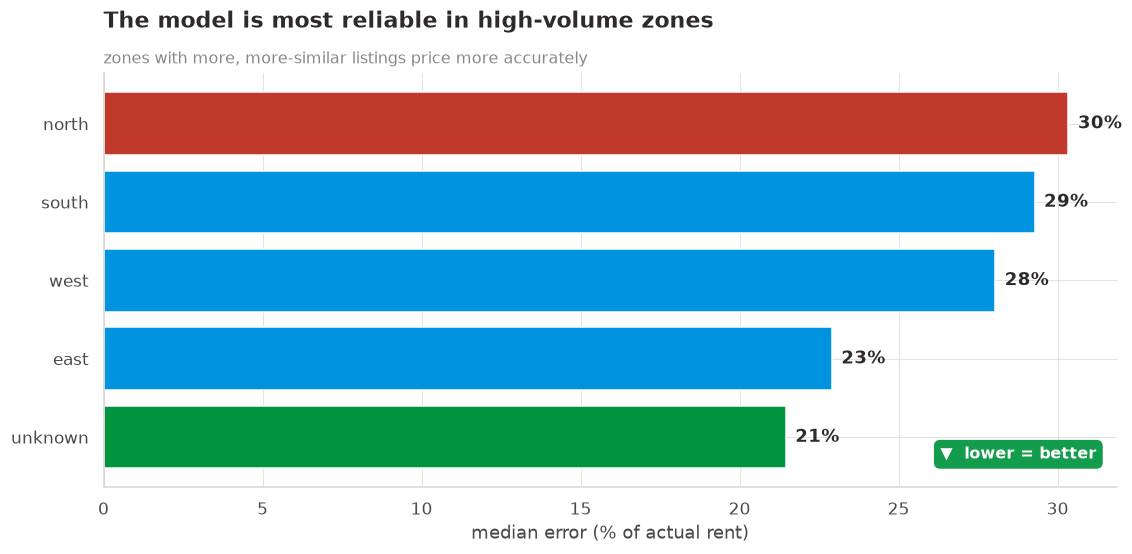

In [4]:
zerr = s.groupby("zone")["ape"].median().sort_values()
fig, ax = plt.subplots(figsize=(10.5, 5.2))
bars = ax.barh(zerr.index, zerr.values, color=[style.GREEN if v == zerr.min() else
              (style.BAD if v == zerr.max() else style.BLUE) for v in zerr.values])
for i, v in enumerate(zerr.values):
    ax.text(v + 0.3, i, f"{v:.0f}%", va="center", fontweight="bold", color=style.INK)
ax.set_xlabel("median error (% of actual rent)")
style.title(ax, "The model is most reliable in high-volume zones",
            "zones with more, more-similar listings price more accurately")
style.direction_badge(ax, "lower", "lower right")
fig.tight_layout(); style.save(fig, "08_error_by_zone"); plt.show()

## 3 · Where it breaks: error by price band

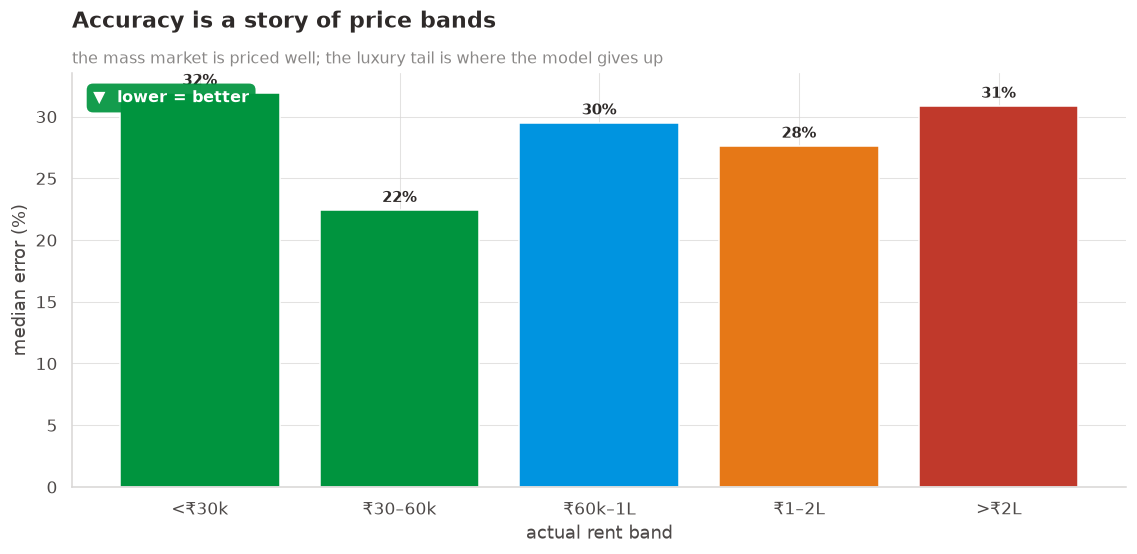

In [5]:
s["band"] = pd.cut(s["rent"], [0, 30000, 60000, 100000, 200000, 1e9],
                   labels=["<₹30k", "₹30–60k", "₹60k–1L", "₹1–2L", ">₹2L"])
berr = s.groupby("band")["ape"].median()
fig, ax = plt.subplots(figsize=(10.5, 5.2))
bars = ax.bar(berr.index.astype(str), berr.values,
              color=[style.GREEN, style.GREEN, style.BLUE, style.ORANGE, style.BAD])
style.bar_labels(ax, fmt="{:.0f}%")
ax.set_ylabel("median error (%)"); ax.set_xlabel("actual rent band")
style.title(ax, "Accuracy is a story of price bands",
            "the mass market is priced well; the luxury tail is where the model gives up")
style.direction_badge(ax, "lower", "upper left")
fig.tight_layout(); style.save(fig, "08_error_by_band"); plt.show()

## 4 · The product: a mispriced-listing detector
The residual *is* the deal signal. Listings far **above** the fair estimate look overpriced;
far **below**, a bargain. This is exactly what a pricing team ships to renters.

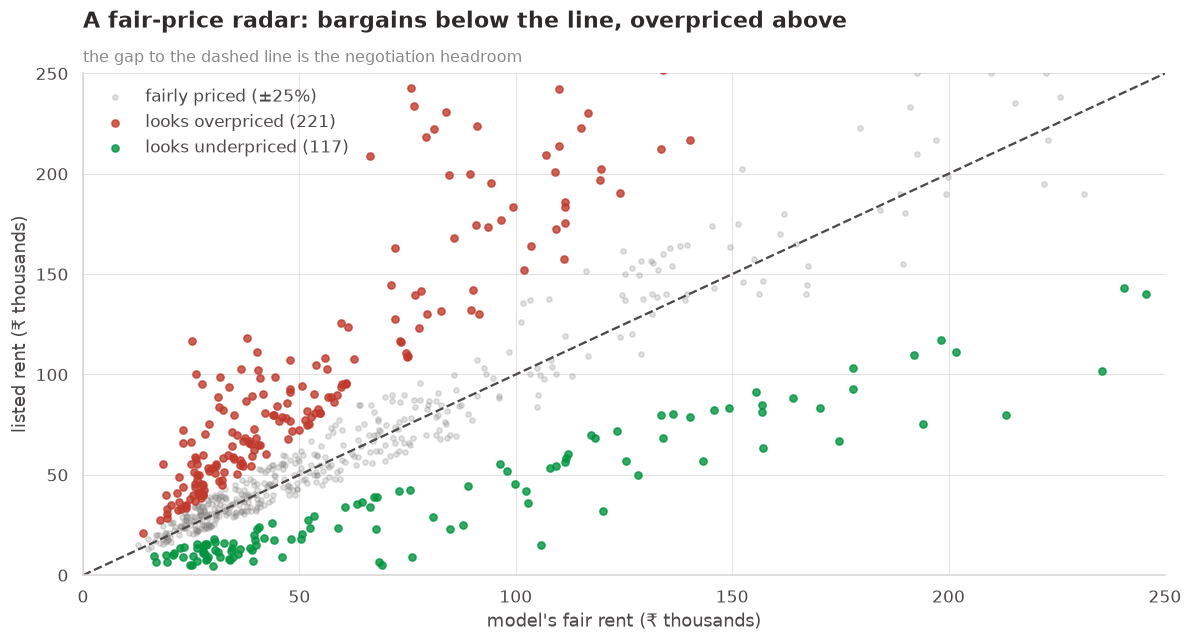

Most overpriced listings (listed ≫ fair):
   locality_name  bhk   size     rent  pred_rent  pct_off
Park Site Colony    2  900.0 735000.0    82570.0    790.0
   Goregaon West    2  818.0 505000.0    57217.0    783.0
      Chandivali    1  631.0 116500.0    25291.0    361.0
          Ghatla    3 1220.0 382500.0    91423.0    318.0
     Bandra West    1  400.0 100000.0    26110.0    283.0

Best bargains (listed ≪ fair):
        locality_name  bhk   size    rent  pred_rent  pct_off
      Waterfield Road    2  755.0  5000.0    69060.0    -93.0
         Andheri West    2  846.0  6500.0    68382.0    -90.0
           Prabhadevi    2  924.0  9000.0    75932.0    -88.0
Thane-Kalyan-Dombivli    3 1220.0 15000.0   105883.0    -86.0
    Sakinaka Junction    1  550.0  4500.0    29997.0    -85.0


In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
ok = s[s["ape"] <= 25]
over = s[s["pct_off"] > 40]
under = s[s["pct_off"] < -40]
ax.scatter(ok["pred_rent"] / 1000, ok["rent"] / 1000, s=12, alpha=0.25, color=style.GREY, label="fairly priced (±25%)")
ax.scatter(over["pred_rent"] / 1000, over["rent"] / 1000, s=22, color=style.BAD, alpha=0.8, label=f"looks overpriced ({len(over)})")
ax.scatter(under["pred_rent"] / 1000, under["rent"] / 1000, s=22, color=style.GREEN, alpha=0.8, label=f"looks underpriced ({len(under)})")
ax.plot([0, 300], [0, 300], color=style.CHARCOAL, ls="--", lw=1.5)
ax.set_xlim(0, 250); ax.set_ylim(0, 250)
ax.set_xlabel("model's fair rent (₹ thousands)"); ax.set_ylabel("listed rent (₹ thousands)")
style.title(ax, "A fair-price radar: bargains below the line, overpriced above",
            "the gap to the dashed line is the negotiation headroom")
ax.legend(loc="upper left")
fig.tight_layout(); style.save(fig, "08_mispriced_detector"); plt.show()

print("Most overpriced listings (listed ≫ fair):")
print(over.nlargest(5, "pct_off")[["locality_name", "bhk", "size", "rent", "pred_rent", "pct_off"]].round(0).to_string(index=False))
print("\nBest bargains (listed ≪ fair):")
print(under.nsmallest(5, "pct_off")[["locality_name", "bhk", "size", "rent", "pred_rent", "pct_off"]].round(0).to_string(index=False))

## 5 · The price map of Mumbai
Every listing at its real coordinates, coloured by predicted fair rent. Location reappears
here — not through amenity counts, but as the raw geography of where money lives.

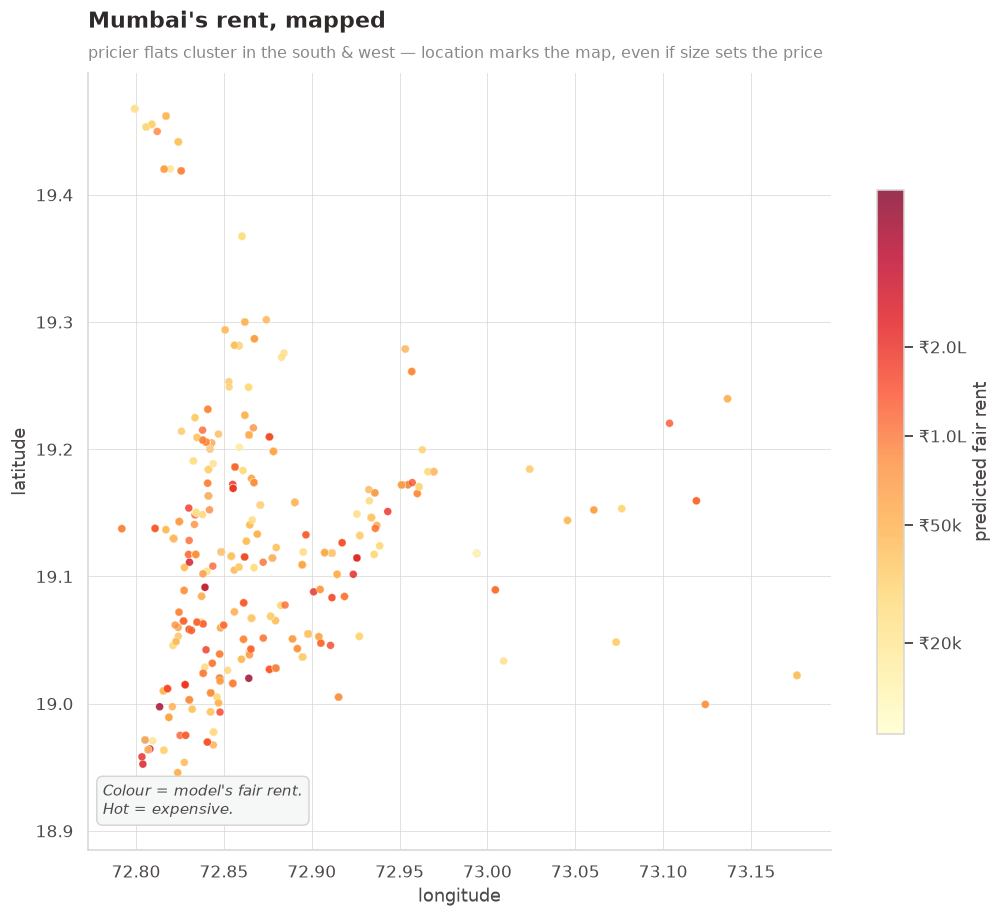

In [7]:
geo = s.dropna(subset=["latitude", "longitude"])
fig, ax = plt.subplots(figsize=(9.5, 8.5))
sc = ax.scatter(geo["longitude"], geo["latitude"], c=np.log10(geo["pred_rent"]),
                cmap="YlOrRd", s=26, alpha=0.8, edgecolor="white", linewidth=0.2)
cb = fig.colorbar(sc, ax=ax, shrink=0.7)
ticks = [20000, 50000, 100000, 200000]
cb.set_ticks([np.log10(t) for t in ticks]); cb.set_ticklabels([style.rupee(t) for t in ticks])
cb.set_label("predicted fair rent")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
style.title(ax, "Mumbai's rent, mapped", "pricier flats cluster in the south & west — location marks the map, even if size sets the price")
style.note(ax, "Colour = model's fair rent.\nHot = expensive.", where="lower left")
fig.tight_layout(); style.save(fig, "08_price_map"); plt.show()

## 6 · Is the model biased in any price band? (calibration)

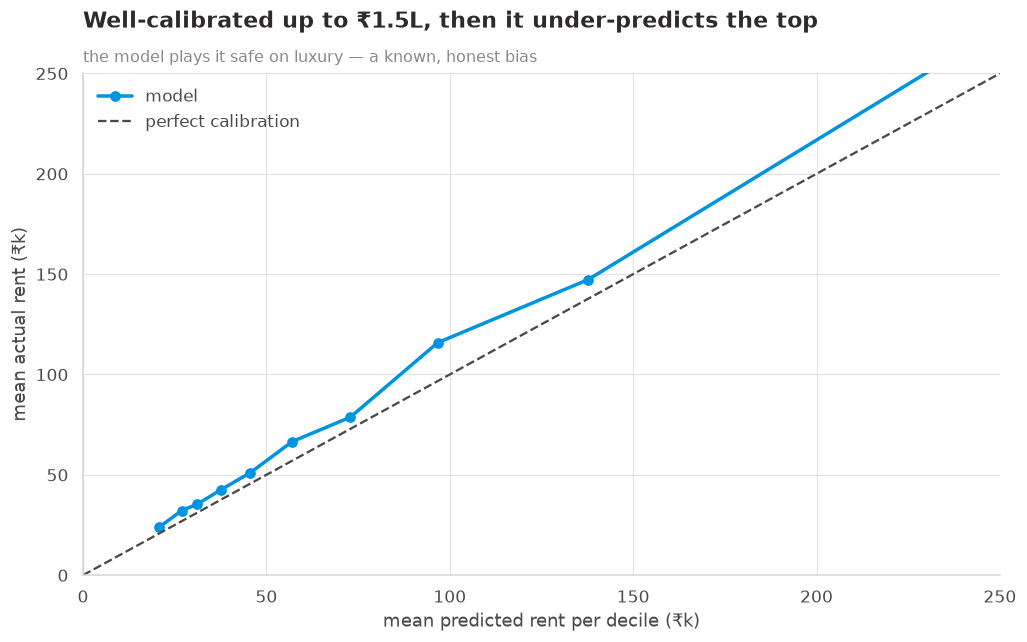

In [8]:
s["dec"] = pd.qcut(s["pred_rent"], 10, labels=False)
cal = s.groupby("dec").agg(pred=("pred_rent", "mean"), actual=("rent", "mean"))
fig, ax = plt.subplots(figsize=(9.5, 6))
ax.plot(cal["pred"] / 1000, cal["actual"] / 1000, "-o", color=style.BLUE, lw=2.3, label="model")
ax.plot([0, 250], [0, 250], color=style.CHARCOAL, ls="--", label="perfect calibration")
ax.set_xlim(0, 250); ax.set_ylim(0, 250)
ax.set_xlabel("mean predicted rent per decile (₹k)"); ax.set_ylabel("mean actual rent (₹k)")
style.title(ax, "Well-calibrated up to ₹1.5L, then it under-predicts the top",
            "the model plays it safe on luxury — a known, honest bias")
ax.legend(loc="upper left")
fig.tight_layout(); style.save(fig, "08_calibration"); plt.show()

### Predictive takeaways
- **Trust band:** below ~₹1L the model is dependable; above ₹2L, treat it as a rough guide.
- **The residual is the product.** Over/under-priced flags turn a rent model into a renter tool.
- **Geography returns** on the map — the premium is *where*, captured by locality, not amenities.
- **Honest bias:** the model under-prices the luxury tail; flag those to a human.